# Image Compression & Reconstruction via Autoencoders
# Parv Bansal (AIMS-DTU)
**Models:** ANN-v1 · ANN-v2 · CNN-v1 · CNN-v2 &nbsp;|&nbsp; **Pipeline:** Image → Encoder → Latent Space → Decoder → Reconstructed Image

In [1]:
# INSTALL 
# !pip3 install torch torchvision matplotlib scikit-learn gdown tqdm pillow notebook

In [2]:
# IMPORTS
import os, time, copy, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, CIFAR10

from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
print(f"PyTorch : {torch.__version__} | Device : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch : 2.11.0 | Device : CPU


In [3]:
# PREMIUM STYLE CONFIG

# Colour palette
P = {
    'ann1'   : '#7C3AED',
    'ann2'   : '#3B82F6',
    'cnn1'   : '#10B981',
    'cnn2'   : '#F43F5E',
    'accent' : '#F59E0B',
    'bg'     : '#0f1117',
    'surface': '#1a1d27',
    'border' : '#2a2d3e',
    'text'   : '#e2e8f0',
    'muted'  : '#64748b',
}
MODEL_COLORS = [P['ann1'], P['ann2'], P['cnn1'], P['cnn2']]

plt.rcParams.update({
    'figure.facecolor'   : P['bg'],      'figure.edgecolor'  : P['bg'],
    'figure.dpi'         : 120,          'figure.titlesize'  : 15,
    'figure.titleweight' : 'bold',
    'axes.facecolor'     : P['surface'], 'axes.edgecolor'    : P['border'],
    'axes.labelcolor'    : P['text'],    'axes.titlecolor'   : P['text'],
    'axes.titlesize'     : 12,           'axes.titleweight'  : 'bold',
    'axes.labelsize'     : 10,           'axes.grid'         : True,
    'axes.spines.top'    : False,        'axes.spines.right' : False,
    'axes.prop_cycle'    : mpl.cycler(color=MODEL_COLORS),
    'grid.color'         : P['border'],  'grid.linewidth'    : 0.6,
    'grid.alpha'         : 0.5,
    'xtick.color'        : P['muted'],   'ytick.color'       : P['muted'],
    'xtick.labelsize'    : 8,            'ytick.labelsize'   : 8,
    'lines.linewidth'    : 2.5,          'lines.solid_capstyle': 'round',
    'legend.facecolor'   : '#1e2130',    'legend.edgecolor'  : P['border'],
    'legend.labelcolor'  : P['text'],    'legend.fontsize'   : 8,
    'legend.framealpha'  : 0.9,
    'font.family'        : 'monospace',  'text.color'        : P['text'],
    'savefig.facecolor'  : P['bg'],      'savefig.bbox'      : 'tight',
    'savefig.dpi'        : 180,
})
print("Theme active.")

Theme active.


In [4]:
# GLOBAL CONFIG
SEED             = 42
IMAGE_SIZE       = 32
BATCH_SIZE       = 64
EPOCHS           = 30
LR               = 1e-3
VAL_SPLIT        = 0.15
NUM_WORKERS      = 0
BOTTLENECK_SMALL = 32
BOTTLENECK_LARGE = 64
CHANNELS         = 3
FLAT_DIM         = CHANNELS * IMAGE_SIZE * IMAGE_SIZE   # 3072

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE} | Flat dim : {FLAT_DIM} | Epochs : {EPOCHS}")

Device : cpu | Flat dim : 3072 | Epochs : 30


In [5]:
# DATASET  (CIFAR-10 — 50k images)
USE_CIFAR = True    
MANUAL_PATH = None  

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

class UnlabeledImageDataset(Dataset):
    EXTS = ('.jpg','.jpeg','.png','.bmp','.webp')
    def __init__(self, root, transform=None):
        self.transform = transform
        self.paths = [
            os.path.join(dp, f)
            for dp, _, fns in os.walk(root)
            for f in fns if f.lower().endswith(self.EXTS)
        ]
        print(f"Found {len(self.paths)} images in {root}")
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return (self.transform(img) if self.transform else img), 0

if MANUAL_PATH and os.path.isdir(MANUAL_PATH):
    full_dataset = UnlabeledImageDataset(MANUAL_PATH, transform)
    test_sz = max(1, int(0.1*len(full_dataset)))
    full_dataset, test_dataset = random_split(full_dataset,
        [len(full_dataset)-test_sz, test_sz],
        generator=torch.Generator().manual_seed(SEED))
    CLASS_NAMES = []
else:
    full_dataset = CIFAR10('./cifar10', train=True,  download=True, transform=transform)
    test_dataset = CIFAR10('./cifar10', train=False, download=True, transform=transform)
    CLASS_NAMES  = full_dataset.classes

val_sz   = int(VAL_SPLIT * len(full_dataset))
train_ds, val_ds = random_split(full_dataset,
    [len(full_dataset)-val_sz, val_sz],
    generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train : {len(train_ds):,}  |  Val : {len(val_ds):,}  |  Test : {len(test_dataset):,}")
print(f"Classes : {CLASS_NAMES}")

Train : 42,500  |  Val : 7,500  |  Test : 10,000
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


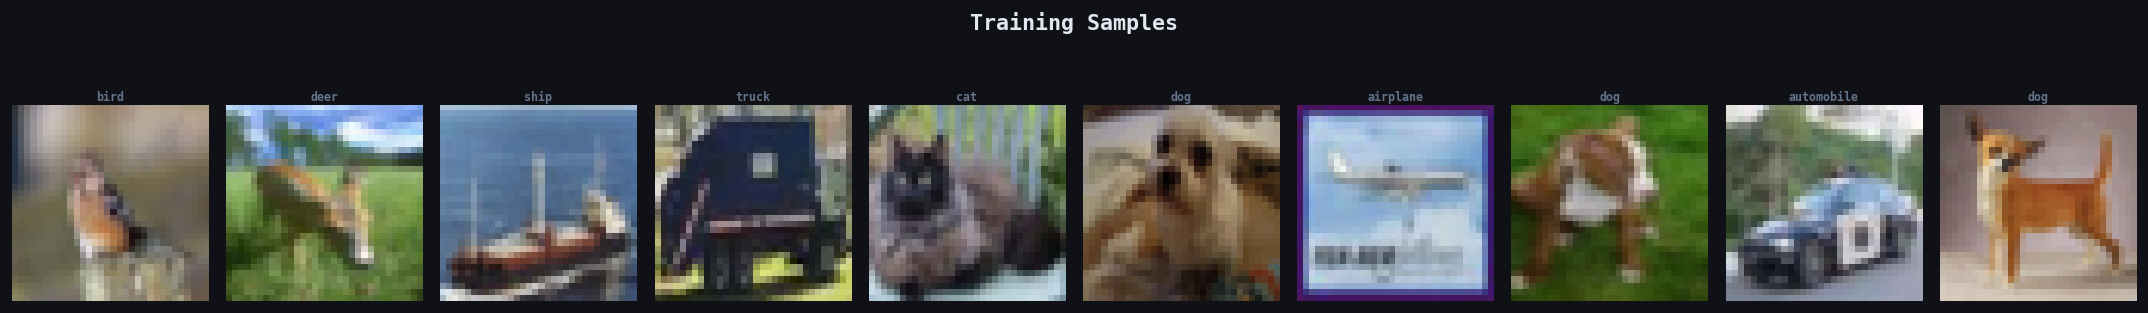

In [6]:
# VISUALISE TRAINING SAMPLES  (premium grid)
def denorm(t): return t * 0.5 + 0.5

def show_sample_grid(loader, title='Training Samples', n=10):
    imgs, lbls = next(iter(loader))
    imgs = denorm(imgs[:n])

    fig, axes = plt.subplots(1, n, figsize=(n*1.8, 2.6))
    fig.patch.set_facecolor(P['bg'])
    fig.suptitle(title, fontsize=13, fontweight='bold',
                 color=P['text'], y=1.05, fontfamily='monospace')

    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1,2,0).numpy().clip(0,1))
        ax.set_facecolor(P['surface'])
        ax.axis('off')
        lbl = CLASS_NAMES[lbls[i]] if CLASS_NAMES else str(i)
        ax.set_title(lbl, fontsize=7, color=P['muted'], pad=3)
        for spine in ax.spines.values():
            spine.set_edgecolor(P['border'])
            spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig('sample_grid.png')
    plt.show()

show_sample_grid(train_loader)

In [7]:
# MODEL 1 : ANN Autoencoder v1
# Shallow FC  |  Bottleneck = 32
class ANN_AE_v1(nn.Module):
    """
    ANN Autoencoder — Shallow
    Encoder : 3072 → 512 → 128 → 32
    Decoder : 32   → 128 → 512 → 3072
    """
    def __init__(self, input_dim=FLAT_DIM, bottleneck=BOTTLENECK_SMALL):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(True),
            nn.Linear(512, 128),       nn.ReLU(True),
            nn.Linear(128, bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.ReLU(True),
            nn.Linear(128, 512),        nn.ReLU(True),
            nn.Linear(512, input_dim),  nn.Tanh()
        )
    def forward(self, x):
        B = x.size(0)
        z = self.encoder(x.view(B,-1))
        return self.decoder(z).view(B,CHANNELS,IMAGE_SIZE,IMAGE_SIZE), z

model_ann1 = ANN_AE_v1().to(DEVICE)
print(f'[ANN-v1]  params: {sum(p.numel() for p in model_ann1.parameters()):,}  | bottleneck: {BOTTLENECK_SMALL}')

[ANN-v1]  params: 3,289,376  | bottleneck: 32


In [8]:
# MODEL 2 : ANN Autoencoder v2
# Deep FC + BatchNorm + Dropout  |  Bottleneck = 64
class ANN_AE_v2(nn.Module):
    """
    ANN Autoencoder — Deep + Regularised
    Encoder : 3072 → 1024 → 512 → 256 → 128 → 64
    Decoder : 64   → 128  → 256 → 512 → 1024 → 3072
    """
    def __init__(self, input_dim=FLAT_DIM, bottleneck=BOTTLENECK_LARGE, drop=0.2):
        super().__init__()
        self.bottleneck = bottleneck
        def blk(a,b): return nn.Sequential(
            nn.Linear(a,b), nn.BatchNorm1d(b), nn.LeakyReLU(0.2,True), nn.Dropout(drop))
        self.encoder = nn.Sequential(
            blk(input_dim,1024), blk(1024,512), blk(512,256), blk(256,128),
            nn.Linear(128,bottleneck)
        )
        self.decoder = nn.Sequential(
            blk(bottleneck,128), blk(128,256), blk(256,512), blk(512,1024),
            nn.Linear(1024,input_dim), nn.Tanh()
        )
    def forward(self, x):
        B = x.size(0)
        z = self.encoder(x.view(B,-1))
        return self.decoder(z).view(B,CHANNELS,IMAGE_SIZE,IMAGE_SIZE), z

model_ann2 = ANN_AE_v2().to(DEVICE)
print(f'[ANN-v2]  params: {sum(p.numel() for p in model_ann2.parameters()):,}  | bottleneck: {BOTTLENECK_LARGE}')

[ANN-v2]  params: 7,698,752  | bottleneck: 64


In [9]:
# MODEL 3 : CNN Autoencoder v1
# Standard ConvNet  |  Bottleneck = 32
class CNN_AE_v1(nn.Module):
    """
    CNN Autoencoder — Standard
    Encoder : 32x32x3 → Conv×3 → 4x4x128 → FC(32)
    Decoder : FC(2048) → ConvT×3 → 32x32x3
    """
    def __init__(self, bottleneck=BOTTLENECK_SMALL):
        super().__init__()
        self.bottleneck = bottleneck
        self.sp = IMAGE_SIZE // 8   # 4
        self.fd = 128 * self.sp**2  # 2048
        def cblk(ci,co): return nn.Sequential(
            nn.Conv2d(ci,co,3,stride=2,padding=1), nn.BatchNorm2d(co), nn.ReLU(True))
        def tblk(ci,co,last=False):
            l = [nn.ConvTranspose2d(ci,co,4,stride=2,padding=1)]
            return nn.Sequential(*l, nn.Tanh()) if last else nn.Sequential(*l, nn.BatchNorm2d(co), nn.ReLU(True))
        self.enc_conv = nn.Sequential(cblk(3,32), cblk(32,64), cblk(64,128))
        self.enc_fc   = nn.Linear(self.fd, bottleneck)
        self.dec_fc   = nn.Linear(bottleneck, self.fd)
        self.dec_conv = nn.Sequential(tblk(128,64), tblk(64,32), tblk(32,3,last=True))
    def encode(self, x):
        return self.enc_fc(self.enc_conv(x).view(x.size(0),-1))
    def decode(self, z):
        return self.dec_conv(self.dec_fc(z).view(-1,128,self.sp,self.sp))
    def forward(self, x):
        z = self.encode(x); return self.decode(z), z

model_cnn1 = CNN_AE_v1().to(DEVICE)
print(f'[CNN-v1]  params: {sum(p.numel() for p in model_cnn1.parameters()):,}  | bottleneck: {BOTTLENECK_SMALL}')

[CNN-v1]  params: 392,515  | bottleneck: 32


In [10]:
# MODEL 4 : CNN Autoencoder v2
# Deep + Residual Blocks  |  Bottleneck = 64
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch))
        self.relu = nn.ReLU(True)
    def forward(self, x): return self.relu(x + self.net(x))

class CNN_AE_v2(nn.Module):
    """
    CNN Autoencoder — Deep + Residual
    Encoder : 32x32 → 4 stride-2 Conv blocks + ResBlocks → FC(64)
    Decoder : FC → 4 ConvTranspose blocks + ResBlocks → 32x32
    """
    def __init__(self, bottleneck=BOTTLENECK_LARGE):
        super().__init__()
        self.bottleneck = bottleneck
        self.sp = IMAGE_SIZE // 16  # 2
        self.fd = 512 * self.sp**2  # 2048
        def ds(ci,co): return nn.Sequential(
            nn.Conv2d(ci,co,4,stride=2,padding=1), nn.BatchNorm2d(co), nn.ReLU(True))
        def us(ci,co): return nn.Sequential(
            nn.ConvTranspose2d(ci,co,4,stride=2,padding=1), nn.BatchNorm2d(co), nn.ReLU(True))
        self.enc = nn.Sequential(
            ds(3,64),  ResBlock(64),
            ds(64,128),  ResBlock(128),
            ds(128,256), ResBlock(256),
            ds(256,512), ResBlock(512))
        self.enc_fc = nn.Linear(self.fd, bottleneck)
        self.dec_fc = nn.Linear(bottleneck, self.fd)
        self.dec = nn.Sequential(
            ResBlock(512), us(512,256),
            ResBlock(256), us(256,128),
            ResBlock(128), us(128,64),
            ResBlock(64),  us(64,3),
            nn.Tanh())
    def encode(self, x):
        return self.enc_fc(self.enc(x).view(x.size(0),-1))
    def decode(self, z):
        return self.dec(self.dec_fc(z).view(-1,512,self.sp,self.sp))
    def forward(self, x):
        z = self.encode(x); return self.decode(z), z

model_cnn2 = CNN_AE_v2().to(DEVICE)
print(f'[CNN-v2]  params: {sum(p.numel() for p in model_cnn2.parameters()):,}  | bottleneck: {BOTTLENECK_LARGE}')

[CNN-v2]  params: 18,324,937  | bottleneck: 64


In [11]:
# TRAINING ENGINE
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, name='model'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {'train': [], 'val': []}
    best_val  = float('inf')
    best_state = None

    bar = '━'
    print(f"\n  {'━'*52}")
    print(f"   {name}")
    print(f"  {'━'*52}")
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train()
        tloss = 0.0
        for imgs,_ in train_loader:
            imgs = imgs.to(DEVICE)
            recon,_ = model(imgs)
            loss = criterion(recon, imgs)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tloss += loss.item() * imgs.size(0)
        tloss /= len(train_loader.dataset)

        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for imgs,_ in val_loader:
                imgs = imgs.to(DEVICE)
                recon,_ = model(imgs)
                vloss += criterion(recon,imgs).item() * imgs.size(0)
        vloss /= len(val_loader.dataset)

        scheduler.step()
        history['train'].append(tloss)
        history['val'].append(vloss)

        if vloss < best_val:
            best_val  = vloss
            best_state = copy.deepcopy(model.state_dict())

        if ep % 5 == 0 or ep == 1:
            dt = time.time()-t0
            print(f"  Ep {ep:3d}/{epochs}  train={tloss:.5f}  val={vloss:.5f}"
                  f"  best={best_val:.5f}  [{dt:.0f}s]")

    print(f"  Done — best val: {best_val:.5f}")
    model.load_state_dict(best_state)
    return history

print('Training engine ready.')

Training engine ready.


In [ ]:
# TRAIN ALL 4 MODELS 
MODELS = {
    'ANN-v1 (BN=32)': model_ann1,
    'ANN-v2 (BN=64)': model_ann2,
    'CNN-v1 (BN=32)': model_cnn1,
    'CNN-v2 (BN=64)': model_cnn2,
}
ALL_HIST = {}

for name, model in MODELS.items():
    ALL_HIST[name] = train_model(model, train_loader, val_loader, name=name)
    safe = name.replace(' ','_').replace('=','').replace('(','').replace(')','')
    torch.save(model.state_dict(), f'{safe}.pth')

print('\n  All models trained and saved!')


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ANN-v1 (BN=32)
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ep   1/30  train=0.08110  val=0.06514  best=0.06514  [8s]
  Ep   5/30  train=0.05371  val=0.06109  best=0.05579  [39s]
  Ep  10/30  train=0.05168  val=0.05339  best=0.05339  [75s]


In [ ]:
# LOSS CURVES  
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training & Validation Loss — All Models', color=P['text'])

for ax, key, title in zip(axes, ['train','val'], ['Train Loss','Validation Loss']):
    for (name, hist), color in zip(ALL_HIST.items(), MODEL_COLORS):
        vals = hist[key]
        ax.plot(vals, label=name, color=color, lw=2.5)
        # Shade under curve
        ax.fill_between(range(len(vals)), vals,
                         alpha=0.08, color=color)
        # Mark best point
        best_ep = int(np.argmin(vals))
        ax.scatter(best_ep, vals[best_ep], color=color, s=60, zorder=5,
                   edgecolors='white', linewidths=0.8)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_yscale('log')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('loss_curves.png')
plt.show()
print('Saved → loss_curves.png')

In [ ]:
# RECONSTRUCTION COMPARISON 
def reconstruction_panel(models_dict, loader, n=8, save='reconstructions.png'):
    imgs, lbls = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    n_models = len(models_dict)

    fig = plt.figure(figsize=(n*1.8, (n_models+1)*1.9))
    fig.patch.set_facecolor(P['bg'])

    # Title banner
    fig.text(0.5, 0.99, 'Reconstruction Quality — Original vs Each Model',
             ha='center', va='top', fontsize=13, fontweight='bold',
             color=P['text'], fontfamily='monospace')

    gs = gridspec.GridSpec(n_models+1, n, figure=fig,
                            hspace=0.08, wspace=0.04)

    # Row labels
    row_labels = ['ORIGINAL'] + list(models_dict.keys())
    row_colors = [P['accent']] + MODEL_COLORS

    orig_np = denorm(imgs.cpu()).permute(0,2,3,1).numpy().clip(0,1)

    all_rows = [orig_np]
    for model in models_dict.values():
        model.eval()
        with torch.no_grad():
            recon,_ = model(imgs)
        all_rows.append(denorm(recon.cpu()).permute(0,2,3,1).numpy().clip(0,1))

    for row_i, (row_imgs, label, col) in enumerate(zip(all_rows, row_labels, row_colors)):
        for col_i in range(n):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.imshow(row_imgs[col_i])
            ax.axis('off')
            ax.set_facecolor(P['bg'])
            for sp in ax.spines.values():
                sp.set_edgecolor(col)
                sp.set_linewidth(1.5)
                sp.set_visible(True)
            if col_i == 0:
                ax.set_ylabel(label, fontsize=7.5, color=col,
                              rotation=0, labelpad=52, va='center',
                              fontfamily='monospace', fontweight='bold')

    plt.savefig(save)
    plt.show()
    print(f'Saved → {save}')

reconstruction_panel(MODELS, test_loader)

In [ ]:
# LATENT SPACE  (PCA)
def get_latents(model, loader, max_n=800):
    model.eval()
    Zs, Ys = [], []
    n = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            _, z = model(imgs.to(DEVICE))
            Zs.append(z.cpu().numpy())
            Ys.append(lbls.numpy())
            n += imgs.size(0)
            if n >= max_n: break
    return np.concatenate(Zs)[:max_n], np.concatenate(Ys)[:max_n]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor(P['bg'])
fig.suptitle('Latent Space Visualisation — PCA Projection', color=P['text'])

cmap = plt.get_cmap('tab10')

for ax, (name, model), mcolor in zip(axes, MODELS.items(), MODEL_COLORS):
    Z, Y = get_latents(model, test_loader)
    proj = PCA(n_components=2, random_state=SEED).fit_transform(Z)

    for cls in np.unique(Y):
        mask = Y == cls
        lbl  = CLASS_NAMES[cls] if CLASS_NAMES else str(cls)
        ax.scatter(proj[mask,0], proj[mask,1], s=10, alpha=0.65,
                   color=cmap(cls/10), label=lbl, linewidths=0)

    # Coloured title border
    for sp in ax.spines.values():
        sp.set_edgecolor(mcolor)
        sp.set_linewidth(2)
        sp.set_visible(True)

    ax.set_title(name, color=mcolor, fontsize=10)
    ax.set_xlabel('PC 1', fontsize=8)
    ax.set_ylabel('PC 2', fontsize=8)
    if CLASS_NAMES:
        ax.legend(fontsize=5.5, ncol=2, loc='best')

plt.tight_layout()
plt.savefig('latent_pca.png')
plt.show()
print('Saved → latent_pca.png')

In [ ]:
# t-SNE LATENT SPACE  (best model: CNN-v2)
print('Running t-SNE on CNN-v2 (~2 min)...')
Z, Y = get_latents(model_cnn2, test_loader, max_n=1000)
proj = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000).fit_transform(Z)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(P['bg'])

for cls in np.unique(Y):
    mask = Y == cls
    lbl  = CLASS_NAMES[cls] if CLASS_NAMES else str(cls)
    ax.scatter(proj[mask,0], proj[mask,1], s=14, alpha=0.75,
               color=cmap(cls/10), label=lbl, linewidths=0)

for sp in ax.spines.values():
    sp.set_edgecolor(P['cnn2'])
    sp.set_linewidth(2)
    sp.set_visible(True)

ax.set_title('CNN-v2 — Latent Space (t-SNE)', color=P['cnn2'], fontsize=13)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
if CLASS_NAMES:
    ax.legend(fontsize=8, ncol=2, loc='best')

plt.tight_layout()
plt.savefig('latent_tsne_cnn2.png')
plt.show()
print('Saved → latent_tsne_cnn2.png')

In [ ]:
# METRICS TABLE  (MSE + PSNR)
def psnr(mse): return 20*np.log10(2.0) - 10*np.log10(mse) if mse>0 else float('inf')

def eval_model(model, loader):
    model.eval()
    crit = nn.MSELoss()
    tot, n = 0.0, 0
    with torch.no_grad():
        for imgs,_ in loader:
            imgs = imgs.to(DEVICE)
            recon,_ = model(imgs)
            tot += crit(recon,imgs).item()*imgs.size(0); n+=imgs.size(0)
    mse = tot/n
    return mse, psnr(mse), sum(p.numel() for p in model.parameters())

print(f"\n{'━'*65}")
print(f"  {'Model':<22} {'Type':<5} {'BN':>4} {'Params':>9} {'MSE':>10} {'PSNR':>9}")
print(f"{'━'*65}")
results = {}
for (name, model), color in zip(MODELS.items(), MODEL_COLORS):
    mse, snr, params = eval_model(model, test_loader)
    bn   = model.bottleneck
    mtype = 'ANN' if 'ANN' in name else 'CNN'
    print(f"  {name:<22} {mtype:<5} {bn:>4} {params/1e6:>8.3f}M {mse:>10.6f} {snr:>8.2f}dB")
    results[name] = {'mse': mse, 'psnr': snr, 'params': params}
print(f"{'━'*65}")
best = max(results, key=lambda k: results[k]['psnr'])
print(f"   Best: {best}  (PSNR = {results[best]['psnr']:.2f} dB)")
print(f"{'━'*65}")

In [ ]:
# LATENT INTERPOLATION 
# Smoothly traverse from Image A → Image B through latent space
def interpolate(model, loader, model_name, steps=10, save=None):
    model.eval()
    imgs,_ = next(iter(loader))
    a, b = imgs[[0]].to(DEVICE), imgs[[1]].to(DEVICE)

    with torch.no_grad():
        if hasattr(model, 'encode'):
            z1, z2 = model.encode(a), model.encode(b)
        else:
            _, z1 = model(a); _, z2 = model(b)

    alphas  = np.linspace(0, 1, steps)
    decoded = []
    for al in alphas:
        z = (1-al)*z1 + al*z2
        with torch.no_grad():
            out = model.decode(z) if hasattr(model,'decode') \
                  else model.decoder(z).view(-1,CHANNELS,IMAGE_SIZE,IMAGE_SIZE)
        decoded.append(denorm(out.cpu()[0]).permute(1,2,0).numpy().clip(0,1))

    total = steps + 2
    fig, axes = plt.subplots(1, total, figsize=(total*1.8, 2.8))
    fig.patch.set_facecolor(P['bg'])
    fig.suptitle(f'{model_name} — Latent Space Interpolation  A ──► B',
                 color=P['text'], fontsize=11, y=1.05)

    axes[0].imshow(denorm(imgs[0]).permute(1,2,0).numpy().clip(0,1))
    axes[0].set_title('A', color=P['accent'], fontsize=9); axes[0].axis('off')

    for i, img in enumerate(decoded):
        axes[i+1].imshow(img)
        axes[i+1].set_title(f'α={alphas[i]:.1f}', fontsize=7, color=P['muted'])
        axes[i+1].axis('off')

    axes[-1].imshow(denorm(imgs[1]).permute(1,2,0).numpy().clip(0,1))
    axes[-1].set_title('B', color=P['accent'], fontsize=9); axes[-1].axis('off')

    plt.tight_layout()
    if save: plt.savefig(save)
    plt.show()

interpolate(model_cnn2, test_loader, 'CNN-v2 (Residual)', save='interp_cnn2.png')
interpolate(model_ann2, test_loader, 'ANN-v2 (Deep)',     save='interp_ann2.png')

In [ ]:
# GRAND SUMMARY FIGURE  (the hero image)
fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor(P['bg'])

gs_outer = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                              height_ratios=[1.2, 1.4, 1.0])

# ── ROW 0: Loss curves ───────────────────────────────────────
gs0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.3)
for col_i, (key, title) in enumerate([('train','Train Loss'), ('val','Val Loss')]):
    ax = fig.add_subplot(gs0[col_i])
    for (name, hist), color in zip(ALL_HIST.items(), MODEL_COLORS):
        vals = hist[key]
        ax.plot(vals, color=color, label=name, lw=2.5)
        ax.fill_between(range(len(vals)), vals, alpha=0.07, color=color)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.set_yscale('log'); ax.legend(fontsize=8)

# ── ROW 1: Reconstructions ───────────────────────────────────
imgs_s, _ = next(iter(test_loader))
imgs_s = imgs_s[:6].to(DEVICE)
orig_s = denorm(imgs_s.cpu()).permute(0,2,3,1).numpy().clip(0,1)

gs1 = gridspec.GridSpecFromSubplotSpec(len(MODELS)+1, 6, subplot_spec=gs_outer[1],
                                        hspace=0.05, wspace=0.03)
row_labels2 = ['ORIGINAL'] + list(MODELS.keys())
row_colors2 = [P['accent']] + MODEL_COLORS
all_recons  = [orig_s]
for m in MODELS.values():
    m.eval()
    with torch.no_grad(): r,_ = m(imgs_s)
    all_recons.append(denorm(r.cpu()).permute(0,2,3,1).numpy().clip(0,1))

for ri, (row_img, rl, rc) in enumerate(zip(all_recons, row_labels2, row_colors2)):
    for ci in range(6):
        ax = fig.add_subplot(gs1[ri, ci])
        ax.imshow(row_img[ci]); ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor(rc); sp.set_linewidth(1.2); sp.set_visible(True)
        if ci == 0:
            ax.set_ylabel(rl, fontsize=7, color=rc, rotation=0,
                          labelpad=48, va='center', fontfamily='monospace')

# ── ROW 2: PCA latent space ───────────────────────────────────
gs2 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_outer[2], wspace=0.3)
for col_i, (name, model) in enumerate(MODELS.items()):
    ax = fig.add_subplot(gs2[col_i])
    Z, Y = get_latents(model, test_loader, 500)
    proj = PCA(2, random_state=SEED).fit_transform(Z)
    for cls in np.unique(Y):
        mask = Y==cls
        ax.scatter(proj[mask,0], proj[mask,1], s=8, alpha=0.6,
                   color=cmap(cls/10), linewidths=0)
    mc = MODEL_COLORS[col_i]
    for sp in ax.spines.values(): sp.set_edgecolor(mc); sp.set_linewidth(2); sp.set_visible(True)
    ax.set_title(name, color=mc, fontsize=9)
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)

fig.text(0.5, 0.99, '  Autoencoder Analysis — Summary Report',
         ha='center', va='top', fontsize=16, fontweight='bold',
         color=P['text'], fontfamily='monospace')

plt.savefig('summary_report.png')
plt.show()
print('  summary_report.png saved — this is your hero figure!')

In [ ]:
# COMPRESSION RATIO ANALYSIS  
orig_dim = FLAT_DIM
bns   = [BOTTLENECK_SMALL, BOTTLENECK_LARGE, BOTTLENECK_SMALL, BOTTLENECK_LARGE]
ratios = [round(orig_dim/b, 1) for b in bns]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(P['bg'])

bars = ax.bar(list(MODELS.keys()), ratios, color=MODEL_COLORS,
               edgecolor=P['border'], linewidth=1.2, width=0.55)

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
            f'{ratio:.0f}×', ha='center', va='bottom',
            color=P['text'], fontsize=11, fontweight='bold')

ax.set_title('Compression Ratio  (Input Dim / Bottleneck Dim)',
             color=P['text'])
ax.set_ylabel('Compression Ratio')
ax.set_xlabel('Model')
ax.axhline(y=0, color=P['border'], linewidth=0.5)

plt.tight_layout()
plt.savefig('compression_ratio.png')
plt.show()
print(f'Input dimension: {orig_dim}  |  Bottleneck sizes: {bns}')

In [ ]:
# FINAL SUMMARY PRINT

print('\n' + '━'*65)
print('     FINAL RESULTS')
print('━'*65)
print(f"  {'Model':<22} {'BN':>4} {'Params':>9} {'Test MSE':>10} {'PSNR':>10} {'Ratio':>8}")
print('─'*65)
for (name, r), bn in zip(results.items(), bns):
    ratio = round(FLAT_DIM/bn, 0)
    print(f"  {name:<22} {bn:>4} {r['params']/1e6:>8.3f}M {r['mse']:>10.6f} "
          f"{r['psnr']:>9.2f}dB {ratio:>6.0f}x")
print('━'*65)
print(f"    Best PSNR : {best}  ({results[best]['psnr']:.2f} dB)")
print('━'*65)
print('\n  Saved outputs:')
for f in ['loss_curves.png','reconstructions.png','latent_pca.png',
          'latent_tsne_cnn2.png','summary_report.png',
          'compression_ratio.png','interp_cnn2.png','interp_ann2.png']:
    if os.path.exists(f): print(f'      {f}')